# Compound-Token Transformer for Next Song or `SKIP`

This notebook implements a **simple causal Transformer** for your setup:

- Song token uses compound features:  
  \(X_i = (\text{title},\ \text{genre},\ \text{bpm})\)
- Song embedding is additive:  
  \(e_i = E_{title}(i) + E_{genre}(i) + E_{bpm}(i)\)
- `SKIP` has its own learned embedding.
- Objective: predict the **next token** in sequence (`next song` or `SKIP`).

Sequence construction (session order):
- Always append song token.
- If that song was skipped, append `SKIP` token immediately after it.

So the model learns transitions like:
`... -> song_A -> SKIP -> song_B -> ...`


In [1]:
import os
import tarfile
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


/Users/caroltu/stat4830real/STAT-4830-Vanishing-Gradients-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

- Update column candidates if your local dataset uses different names.
- If your dataset has no genre/title columns, this notebook will still run by using defaults (`track_id_clean` for title, `<UNK_GENRE>` for genre).


In [2]:
CONFIG = {
    # Data locations
    "tar_path_candidates": [
        "./spotify_skip_prediction_mini.tar",
        "../spotify_skip_prediction_mini.tar",
        "/content/drive/MyDrive/STAT 4830 Project/spotify_skip_prediction_mini.tar",
    ],
    "extract_dir": "./extracted_files",
    "log_rel_path": "data/training_set/log_mini.csv",
    "track_rel_path": "data/track_features/tf_mini.csv",

    # Core columns
    "session_col": "session_id",
    "position_col": "session_position",
    "title_col_candidates": ["title", "track_name", "track_id_clean", "track_id"],
    "genre_col_candidates": ["genre", "genre_name", "track_genre"],
    "bpm_col_candidates": ["bpm", "tempo"],
    "skip_col_candidates": ["skip_2", "skipped", "not_skipped"],

    # Training setup
    "test_size": 0.20,
    "max_sessions": None,      # Set an int (e.g. 3000) for faster experiments
    "min_title_freq": 2,       # Rare titles map to <UNK_TITLE>
    "max_seq_len": 40,

    # Model hyperparameters
    "d_model": 128,
    "nhead": 4,
    "num_layers": 2,
    "ff_dim": 256,
    "dropout": 0.10,

    # Optimization
    "batch_size": 256,
    "epochs": 5,
    "lr": 3e-4,
    "weight_decay": 1e-4,
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


In [3]:
def pick_first_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None


def pick_existing_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of these columns were found: {candidates}")
    return None


def load_spotify_data(config):
    extract_dir = Path(config["extract_dir"])
    log_path = extract_dir / config["log_rel_path"]
    tf_path = extract_dir / config["track_rel_path"]

    if not (log_path.exists() and tf_path.exists()):
        tar_path = pick_first_existing_path(config["tar_path_candidates"])
        if tar_path is None:
            msg = (
                "Could not find spotify tar file.\n"
                "Place it in project root as spotify_skip_prediction_mini.tar\n"
                "or update CONFIG['tar_path_candidates']."
            )
            raise FileNotFoundError(msg)

        extract_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(tar_path, "r") as tar:
            tar.extractall(path=extract_dir)
        print(f"Extracted: {tar_path} -> {extract_dir}")

    df_log = pd.read_csv(log_path)
    df_tf = pd.read_csv(tf_path)

    # Flexible merge
    if "track_id_clean" in df_log.columns and "track_id" in df_tf.columns:
        df = pd.merge(df_log, df_tf, left_on="track_id_clean", right_on="track_id", how="left")
    elif "track_id" in df_log.columns and "track_id" in df_tf.columns:
        df = pd.merge(df_log, df_tf, on="track_id", how="left")
    else:
        raise KeyError("Could not find compatible track-id columns to merge logs and track features.")

    return df_log, df_tf, df


df_log, df_tf, df_merged = load_spotify_data(CONFIG)
print("log shape:", df_log.shape)
print("track shape:", df_tf.shape)
print("merged shape:", df_merged.shape)

df_merged.head()


log shape: (167880, 21)
track shape: (50704, 30)
merged shape: (167880, 51)


,session_id,session_position,session_length,track_id_clean,skip_1,skip_2,skip_3,not_skipped,context_switch,no_pause_before_play,...,time_signature,valence,acoustic_vector_0,acoustic_vector_1,acoustic_vector_2,acoustic_vector_3,acoustic_vector_4,acoustic_vector_5,acoustic_vector_6,acoustic_vector_7
0,0_00006f66-33e5-4de7-a324-2d18e439fc1e,1,20,t_0479f24c-27d2-46d6-a00c-7ec928f2b539,False,False,False,True,0,0,...,4,0.152255,-0.815775,0.386409,0.230160,0.028028,-0.333373,0.015452,-0.353590,0.205826
1,0_00006f66-33e5-4de7-a324-2d18e439fc1e,2,20,t_9099cd7b-c238-47b7-9381-f23f2c1d1043,False,False,False,True,0,1,...,4,0.337152,-0.713646,0.363718,0.310315,-0.042222,-0.383164,0.066357,-0.365308,0.157920
2,0_00006f66-33e5-4de7-a324-2d18e439fc1e,3,20,t_fc5df5ba-5396-49a7-8b29-35d0d28249e0,False,False,False,True,0,1,...,4,0.373862,-0.742541,0.375599,0.252660,-0.049007,-0.299745,0.063341,-0.486689,0.181604
3,0_00006f66-33e5-4de7-a324-2d18e439fc1e,4,20,t_23cff8d6-d874-4b20-83dc-94e450e8aa20,False,False,False,True,0,1,...,4,0.649420,-0.705116,0.317562,0.289141,-0.038920,-0.393358,0.092719,-0.364418,0.285603
4,0_00006f66-33e5-4de7-a324-2d18e439fc1e,5,20,t_64f3743c-f624-46bb-a579-0f3f9a07a123,False,False,False,True,0,1,...,4,0.652921,-0.868489,0.331280,0.210478,0.084740,-0.333287,-0.025706,-0.510350,0.182315


In [4]:
def build_event_table(df, config):
    session_col = config["session_col"]
    position_col = config["position_col"]

    if session_col not in df.columns or position_col not in df.columns:
        raise KeyError(f"Required columns missing: {session_col}, {position_col}")

    title_col = pick_existing_column(df, config["title_col_candidates"], required=True)
    genre_col = pick_existing_column(df, config["genre_col_candidates"], required=False)
    bpm_col = pick_existing_column(df, config["bpm_col_candidates"], required=False)
    skip_col = pick_existing_column(df, config["skip_col_candidates"], required=True)

    out = df[[session_col, position_col, title_col]].copy()

    # Genre fallback
    if genre_col is None:
        out["genre"] = "<UNK_GENRE>"
    else:
        out["genre"] = df[genre_col].astype(str).fillna("<UNK_GENRE>")

    # BPM fallback
    if bpm_col is None:
        out["bpm"] = 0.0
    else:
        out["bpm"] = pd.to_numeric(df[bpm_col], errors="coerce").fillna(0.0)

    out["title"] = df[title_col].astype(str).fillna("<UNK_TITLE>")

    # Skip label handling
    if skip_col == "not_skipped":
        out["skip"] = (~df[skip_col].astype(bool)).astype(int)
    else:
        out["skip"] = df[skip_col].astype(int)

    out = out.sort_values([session_col, position_col]).reset_index(drop=True)

    if config["max_sessions"] is not None:
        keep_sessions = out[session_col].drop_duplicates().head(config["max_sessions"])
        out = out[out[session_col].isin(set(keep_sessions))].copy()

    return out, {
        "session_col": session_col,
        "position_col": position_col,
        "title_col": title_col,
        "genre_col": genre_col,
        "bpm_col": bpm_col,
        "skip_col": skip_col,
    }


events_df, used_cols = build_event_table(df_merged, CONFIG)
print("Using columns:", used_cols)
print("events shape:", events_df.shape)
events_df.head()


Using columns: {'session_col': 'session_id', 'position_col': 'session_position', 'title_col': 'track_id_clean', 'genre_col': None, 'bpm_col': 'tempo', 'skip_col': 'skip_2'}
events shape: (167880, 7)


,session_id,session_position,track_id_clean,genre,bpm,title,skip
0,0_00006f66-33e5-4de7-a324-2d18e439fc1e,1,t_0479f24c-27d2-46d6-a00c-7ec928f2b539,<UNK_GENRE>,134.024994,t_0479f24c-27d2-46d6-a00c-7ec928f2b539,0
1,0_00006f66-33e5-4de7-a324-2d18e439fc1e,2,t_9099cd7b-c238-47b7-9381-f23f2c1d1043,<UNK_GENRE>,130.037994,t_9099cd7b-c238-47b7-9381-f23f2c1d1043,0
2,0_00006f66-33e5-4de7-a324-2d18e439fc1e,3,t_fc5df5ba-5396-49a7-8b29-35d0d28249e0,<UNK_GENRE>,145.028000,t_fc5df5ba-5396-49a7-8b29-35d0d28249e0,0
3,0_00006f66-33e5-4de7-a324-2d18e439fc1e,4,t_23cff8d6-d874-4b20-83dc-94e450e8aa20,<UNK_GENRE>,111.982002,t_23cff8d6-d874-4b20-83dc-94e450e8aa20,0
4,0_00006f66-33e5-4de7-a324-2d18e439fc1e,5,t_64f3743c-f624-46bb-a579-0f3f9a07a123,<UNK_GENRE>,147.031006,t_64f3743c-f624-46bb-a579-0f3f9a07a123,0


In [5]:
# Split by session so train/test sessions do not overlap
splitter = GroupShuffleSplit(n_splits=1, test_size=CONFIG["test_size"], random_state=42)
train_idx, test_idx = next(splitter.split(events_df, groups=events_df[CONFIG["session_col"]]))

train_df = events_df.iloc[train_idx].copy()
test_df = events_df.iloc[test_idx].copy()

print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train sessions:", train_df[CONFIG["session_col"]].nunique(),
      "| Test sessions:", test_df[CONFIG["session_col"]].nunique())


Train rows: 134268 | Test rows: 33612
Train sessions: 8000 | Test sessions: 2000


## Build Vocabularies and Token Sequences

Special tokens:
- `0` = `<PAD>`
- `1` = `<SKIP>`
- `2..` = song tokens (mapped from `title`)


In [6]:
def build_vocabs_from_train(train_df, min_title_freq=1):
    # Title vocab with frequency cutoff
    counts = train_df["title"].value_counts()
    keep_titles = set(counts[counts >= min_title_freq].index.tolist())

    title_to_idx = {"<UNK_TITLE>": 0}
    for t in sorted(keep_titles):
        if t != "<UNK_TITLE>":
            title_to_idx[t] = len(title_to_idx)

    # Genre vocab
    genre_to_idx = {"<NONE>": 0, "<UNK_GENRE>": 1}
    for g in sorted(train_df["genre"].dropna().astype(str).unique().tolist()):
        if g not in genre_to_idx:
            genre_to_idx[g] = len(genre_to_idx)

    # BPM normalization stats from train only
    bpm_train = pd.to_numeric(train_df["bpm"], errors="coerce")
    bpm_mean = float(bpm_train.mean()) if bpm_train.notna().any() else 0.0
    bpm_std = float(bpm_train.std()) if bpm_train.notna().any() else 1.0
    if not np.isfinite(bpm_std) or bpm_std < 1e-8:
        bpm_std = 1.0

    # Build title-level metadata (genre/bpm) from train only
    tmp = train_df.copy()
    tmp["title_mapped"] = tmp["title"].where(tmp["title"].isin(keep_titles), "<UNK_TITLE>")

    title_meta = {}
    for title, grp in tmp.groupby("title_mapped"):
        g_mode = grp["genre"].astype(str).mode()
        genre = g_mode.iloc[0] if len(g_mode) > 0 else "<UNK_GENRE>"
        if genre not in genre_to_idx:
            genre = "<UNK_GENRE>"

        raw_bpm = pd.to_numeric(grp["bpm"], errors="coerce").median()
        raw_bpm = bpm_mean if pd.isna(raw_bpm) else float(raw_bpm)
        bpm_norm = (raw_bpm - bpm_mean) / bpm_std
        bpm_norm = float(np.clip(bpm_norm, -5.0, 5.0))

        title_meta[title] = {"genre": genre, "bpm": bpm_norm}

    if "<UNK_TITLE>" not in title_meta:
        title_meta["<UNK_TITLE>"] = {"genre": "<UNK_GENRE>", "bpm": 0.0}

    bpm_stats = {"mean": bpm_mean, "std": bpm_std}
    return keep_titles, title_to_idx, genre_to_idx, title_meta, bpm_stats


def encode_titles(df, keep_titles, title_to_idx):
    out = df.copy()
    out["title_mapped"] = out["title"].where(out["title"].isin(keep_titles), "<UNK_TITLE>")
    out["title_idx"] = out["title_mapped"].map(title_to_idx).fillna(0).astype(np.int64)
    out["skip"] = out["skip"].astype(np.int64)
    return out


def build_session_token_sequences(df, session_col, position_col):
    seqs = []
    grouped = df.sort_values([session_col, position_col]).groupby(session_col, sort=False)

    for _, grp in grouped:
        title_idxs = grp["title_idx"].to_numpy(dtype=np.int64)
        skips = grp["skip"].to_numpy(dtype=np.int64)

        seq = []
        for t_idx, sk in zip(title_idxs, skips):
            song_token = int(t_idx) + 2  # 0=PAD,1=SKIP,2..=song
            seq.append(song_token)
            if sk == 1:
                seq.append(1)  # SKIP token

        if len(seq) >= 2:
            seqs.append(seq)

    return seqs


def build_token_lookup_tables(title_to_idx, genre_to_idx, title_meta):
    vocab_size = len(title_to_idx) + 2

    # Feature lookups for each token id
    # title_feature_id: 0 is reserved for pad/skip; song titles are shifted by +1
    token_to_title_feature = np.zeros(vocab_size, dtype=np.int64)
    token_to_genre = np.zeros(vocab_size, dtype=np.int64)
    token_to_bpm = np.zeros(vocab_size, dtype=np.float32)

    for title, title_idx in title_to_idx.items():
        token_id = title_idx + 2
        title_feature_id = title_idx + 1

        token_to_title_feature[token_id] = title_feature_id

        meta = title_meta.get(title, {"genre": "<UNK_GENRE>", "bpm": 0.0})
        token_to_genre[token_id] = genre_to_idx.get(meta["genre"], genre_to_idx["<UNK_GENRE>"])

        bpm_val = float(meta.get("bpm", 0.0))
        if not np.isfinite(bpm_val):
            bpm_val = 0.0
        token_to_bpm[token_id] = bpm_val

    return token_to_title_feature, token_to_genre, token_to_bpm, vocab_size


keep_titles, title_to_idx, genre_to_idx, title_meta, bpm_stats = build_vocabs_from_train(
    train_df,
    min_title_freq=CONFIG["min_title_freq"],
)

train_enc = encode_titles(train_df, keep_titles, title_to_idx)
test_enc = encode_titles(test_df, keep_titles, title_to_idx)

train_seqs = build_session_token_sequences(
    train_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
)
test_seqs = build_session_token_sequences(
    test_enc,
    CONFIG["session_col"],
    CONFIG["position_col"],
)

token_to_title_feature, token_to_genre, token_to_bpm, vocab_size = build_token_lookup_tables(
    title_to_idx,
    genre_to_idx,
    title_meta,
)

print("#train sequences:", len(train_seqs))
print("#test sequences:", len(test_seqs))
print("token vocab size:", vocab_size)
print("title vocab size:", len(title_to_idx))
print("genre vocab size:", len(genre_to_idx))
print("BPM stats (train):", bpm_stats)
print("token_to_bpm finite:", np.isfinite(token_to_bpm).all())


#train sequences: 8000
#test sequences: 2000
token vocab size: 15815
title vocab size: 15813
genre vocab size: 2
BPM stats (train): {'mean': 122.73266381217621, 'std': 29.786377272044085}
token_to_bpm finite: True


In [7]:
def make_next_token_examples(sequences, max_seq_len, pad_token_id=0):
    # Each example = (history tokens, next token)
    n_examples = sum(max(0, len(seq) - 1) for seq in sequences)

    X = np.full((n_examples, max_seq_len), pad_token_id, dtype=np.int64)
    A = np.zeros((n_examples, max_seq_len), dtype=np.int64)
    y = np.zeros(n_examples, dtype=np.int64)

    i = 0
    for seq in sequences:
        for t in range(1, len(seq)):
            hist = seq[max(0, t - max_seq_len):t]
            L = len(hist)

            X[i, -L:] = np.array(hist, dtype=np.int64)
            A[i, -L:] = 1
            y[i] = seq[t]
            i += 1

    return X, A, y


X_train, A_train, y_train = make_next_token_examples(train_seqs, CONFIG["max_seq_len"])
X_test, A_test, y_test = make_next_token_examples(test_seqs, CONFIG["max_seq_len"])

print("Train examples:", len(y_train))
print("Test examples:", len(y_test))
print("Skip target rate (train):", np.mean(y_train == 1).round(4))


Train examples: 195480
Test examples: 49224
Skip target rate (train): 0.3541


In [8]:
class NextTokenDataset(Dataset):
    def __init__(self, X, A, y):
        self.X = torch.from_numpy(X).long()
        self.A = torch.from_numpy(A).long()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.y.size(0)

    def __getitem__(self, idx):
        return self.X[idx], self.A[idx], self.y[idx]


train_ds = NextTokenDataset(X_train, A_train, y_train)
test_ds = NextTokenDataset(X_test, A_test, y_test)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)


## Model

For non-skip tokens:
\[
	ext{embed}(x_t)=E_{title}(x_t)+E_{genre}(x_t)+E_{bpm}(x_t)+E_{pos}(t)
\]

For skip tokens:
\[
	ext{embed}(x_t)=E_{skip}+E_{pos}(t)
\]


In [9]:
class CompoundTokenTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        title_vocab_size,
        genre_vocab_size,
        token_to_title_feature,
        token_to_genre,
        token_to_bpm,
        d_model=128,
        nhead=4,
        num_layers=2,
        ff_dim=256,
        max_seq_len=40,
        dropout=0.1,
        pad_token_id=0,
        skip_token_id=1,
    ):
        super().__init__()
        self.pad_token_id = pad_token_id
        self.skip_token_id = skip_token_id

        self.title_emb = nn.Embedding(title_vocab_size, d_model)
        self.genre_emb = nn.Embedding(genre_vocab_size, d_model)
        self.bpm_proj = nn.Linear(1, d_model)
        self.skip_emb = nn.Parameter(torch.zeros(d_model))
        nn.init.normal_(self.skip_emb, mean=0.0, std=0.02)

        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, vocab_size)

        self.register_buffer("token_to_title_feature", torch.tensor(token_to_title_feature, dtype=torch.long))
        self.register_buffer("token_to_genre", torch.tensor(token_to_genre, dtype=torch.long))
        self.register_buffer("token_to_bpm", torch.tensor(token_to_bpm, dtype=torch.float32))

    def _causal_mask(self, seq_len, device):
        # bool mask to match src_key_padding_mask dtype expectations
        return torch.triu(
            torch.ones((seq_len, seq_len), device=device, dtype=torch.bool),
            diagonal=1,
        )

    def forward(self, input_token_ids, attention_mask):
        # input_token_ids: [B, L]
        B, L = input_token_ids.shape

        title_ids = self.token_to_title_feature[input_token_ids]  # [B, L]
        genre_ids = self.token_to_genre[input_token_ids]          # [B, L]

        bpm_vals = self.token_to_bpm[input_token_ids]
        bpm_vals = torch.nan_to_num(bpm_vals, nan=0.0, posinf=0.0, neginf=0.0).unsqueeze(-1)  # [B, L, 1]

        song_embed = self.title_emb(title_ids) + self.genre_emb(genre_ids) + self.bpm_proj(bpm_vals)
        song_embed = torch.nan_to_num(song_embed, nan=0.0, posinf=1e4, neginf=-1e4)

        skip_mask = (input_token_ids == self.skip_token_id).unsqueeze(-1)
        skip_embed = self.skip_emb.view(1, 1, -1)
        x = torch.where(skip_mask, skip_embed, song_embed)

        pos_ids = torch.arange(L, device=input_token_ids.device).unsqueeze(0)
        x = x + self.pos_emb(pos_ids)
        x = self.dropout(x)
        x = torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)

        key_padding_mask = attention_mask == 0
        causal_mask = self._causal_mask(L, input_token_ids.device)

        h = self.encoder(x, mask=causal_mask, src_key_padding_mask=key_padding_mask)

        lengths = attention_mask.sum(dim=1).clamp(min=1)
        last_idx = lengths - 1
        last_h = h[torch.arange(B, device=input_token_ids.device), last_idx]

        logits = self.out(last_h)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)

        # PAD is never a valid target label in this setup
        logits[:, self.pad_token_id] = -1e9
        return logits


model = CompoundTokenTransformer(
    vocab_size=vocab_size,
    title_vocab_size=len(title_to_idx) + 1,  # +1 for feature padding id 0
    genre_vocab_size=len(genre_to_idx),
    token_to_title_feature=token_to_title_feature,
    token_to_genre=token_to_genre,
    token_to_bpm=token_to_bpm,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_layers=CONFIG["num_layers"],
    ff_dim=CONFIG["ff_dim"],
    max_seq_len=CONFIG["max_seq_len"],
    dropout=CONFIG["dropout"],
).to(DEVICE)

model


/var/folders/f_/ltygyh2d33x4m6tkm0zzxw4h0000gn/T/ipykernel_93028/2170088170.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


CompoundTokenTransformer(
  (title_emb): Embedding(15814, 128)
  (genre_emb): Embedding(2, 128)
  (bpm_proj): Linear(in_features=1, out_features=128, bias=True)
  (pos_emb): Embedding(40, 128)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (out): Linear(in_features=128, out_features=15815, bias=T

### Training Progress + Metrics\n
\n
This block adds live training progress (`tqdm`) and stores epoch metrics in `history_df`.\n

In [10]:
def evaluate(model, data_loader, criterion, max_batches=None):
    model.eval()
    total_loss = 0.0
    ys = []
    preds = []
    forced_song_preds = []
    song_top5_hits = []

    with torch.no_grad():
        for bidx, (x, a, y) in enumerate(data_loader):
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x, a)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)

            loss = criterion(logits, y)
            if not torch.isfinite(loss):
                continue

            total_loss += loss.item() * y.size(0)

            pred = torch.argmax(logits, dim=1)
            ys_np = y.cpu().numpy()
            preds_np = pred.cpu().numpy()

            # Song-only decoding diagnostic:
            # ignores SKIP/PAD competition to measure how well song ranking works.
            song_logits = logits[:, 2:]
            forced_song = torch.argmax(song_logits, dim=1) + 2
            forced_song_np = forced_song.cpu().numpy()

            ys.append(ys_np)
            preds.append(preds_np)
            forced_song_preds.append(forced_song_np)

            song_mask = ys_np != 1
            if song_mask.any():
                topk_song = torch.topk(song_logits[song_mask], k=min(5, song_logits.size(1)), dim=1).indices.cpu().numpy() + 2
                true_song = ys_np[song_mask][:, None]
                hits = (topk_song == true_song).any(axis=1).astype(np.int64)
                song_top5_hits.append(hits)

            if max_batches is not None and (bidx + 1) >= max_batches:
                break

    if len(ys) == 0:
        return {
            'loss': np.nan,
            'overall_acc': 0.0,
            'song_acc': 0.0,
            'song_forced_acc': 0.0,
            'song_top5_acc': 0.0,
            'skip_precision': 0.0,
            'skip_recall': 0.0,
            'skip_f1': 0.0,
            'pred_skip_rate': 0.0,
            'true_skip_rate': 0.0,
        }

    ys = np.concatenate(ys)
    preds = np.concatenate(preds)
    forced_song_preds = np.concatenate(forced_song_preds)

    overall_acc = accuracy_score(ys, preds)

    song_mask = ys != 1
    song_acc = accuracy_score(ys[song_mask], preds[song_mask]) if song_mask.any() else 0.0
    song_forced_acc = accuracy_score(ys[song_mask], forced_song_preds[song_mask]) if song_mask.any() else 0.0

    if len(song_top5_hits) > 0:
        song_top5_acc = float(np.mean(np.concatenate(song_top5_hits)))
    else:
        song_top5_acc = 0.0

    y_skip = (ys == 1).astype(int)
    p_skip = (preds == 1).astype(int)
    skip_p, skip_r, skip_f1, _ = precision_recall_fscore_support(
        y_skip, p_skip, average='binary', zero_division=0
    )

    avg_loss = total_loss / len(ys)
    return {
        'loss': avg_loss,
        'overall_acc': overall_acc,
        'song_acc': song_acc,
        'song_forced_acc': song_forced_acc,
        'song_top5_acc': song_top5_acc,
        'skip_precision': skip_p,
        'skip_recall': skip_r,
        'skip_f1': skip_f1,
        'pred_skip_rate': float(np.mean(p_skip)),
        'true_skip_rate': float(np.mean(y_skip)),
    }


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)

# Lightweight train split evaluation to show learning dynamics without full-pass slowdown.
train_eval_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=False)
train_eval_batches = 120

history = []

for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    running = 0.0
    seen = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{CONFIG["epochs"]}', leave=False)
    for x, a, y in pbar:
        x = x.to(DEVICE)
        a = a.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x, a)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)

        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        batch_size = y.size(0)
        running += loss.item() * batch_size
        seen += batch_size
        pbar.set_postfix({'batch_loss': f'{loss.item():.4f}'})

    train_loss = (running / seen) if seen > 0 else np.nan

    train_metrics = evaluate(model, train_eval_loader, criterion, max_batches=train_eval_batches)
    test_metrics = evaluate(model, test_loader, criterion)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_eval_loss': train_metrics['loss'],
        'loss': test_metrics['loss'],  # backward-compatible alias for test loss
        'test_loss': test_metrics['loss'],

        'train_acc': train_metrics['overall_acc'],
        'test_acc': test_metrics['overall_acc'],
        'overall_acc': test_metrics['overall_acc'],  # backward-compatible alias

        'train_song_acc': train_metrics['song_acc'],
        'test_song_acc': test_metrics['song_acc'],
        'song_acc': test_metrics['song_acc'],  # backward-compatible alias

        'train_song_forced_acc': train_metrics['song_forced_acc'],
        'test_song_forced_acc': test_metrics['song_forced_acc'],
        'train_song_top5_acc': train_metrics['song_top5_acc'],
        'test_song_top5_acc': test_metrics['song_top5_acc'],

        'train_skip_precision': train_metrics['skip_precision'],
        'train_skip_recall': train_metrics['skip_recall'],
        'train_skip_f1': train_metrics['skip_f1'],

        'skip_precision': test_metrics['skip_precision'],
        'skip_recall': test_metrics['skip_recall'],
        'skip_f1': test_metrics['skip_f1'],

        'train_pred_skip_rate': train_metrics['pred_skip_rate'],
        'test_pred_skip_rate': test_metrics['pred_skip_rate'],
        'train_true_skip_rate': train_metrics['true_skip_rate'],
        'test_true_skip_rate': test_metrics['true_skip_rate'],
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"test_loss={test_metrics['loss']:.4f} | "
        f"test_acc={test_metrics['overall_acc']:.4f} | "
        f"song_acc={test_metrics['song_acc']:.4f} | "
        f"song_forced_acc={test_metrics['song_forced_acc']:.4f} | "
        f"skip_P={test_metrics['skip_precision']:.4f} | "
        f"skip_R={test_metrics['skip_recall']:.4f} | "
        f"skip_F1={test_metrics['skip_f1']:.4f} | "
        f"pred_skip_rate={test_metrics['pred_skip_rate']:.4f}"
    )

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=5.8012 | test_loss=9.6687 | test_acc=0.3578 | song_acc=0.0000 | song_forced_acc=0.3420 | skip_P=0.3578 | skip_R=1.0000 | skip_F1=0.5270 | pred_skip_rate=1.0000


Epoch 02 | train_loss=5.3828 | test_loss=9.6687 | test_acc=0.3578 | song_acc=0.0000 | song_forced_acc=0.3420 | skip_P=0.3578 | skip_R=1.0000 | skip_F1=0.5270 | pred_skip_rate=1.0000


Epoch 03 | train_loss=5.2442 | test_loss=9.6687 | test_acc=0.3578 | song_acc=0.0000 | song_forced_acc=0.3420 | skip_P=0.3578 | skip_R=1.0000 | skip_F1=0.5270 | pred_skip_rate=1.0000


Epoch 04 | train_loss=5.1237 | test_loss=9.6687 | test_acc=0.3578 | song_acc=0.0000 | song_forced_acc=0.3420 | skip_P=0.3578 | skip_R=1.0000 | skip_F1=0.5270 | pred_skip_rate=1.0000


Epoch 05 | train_loss=5.0190 | test_loss=9.6687 | test_acc=0.3578 | song_acc=0.0000 | song_forced_acc=0.3420 | skip_P=0.3578 | skip_R=1.0000 | skip_F1=0.5270 | pred_skip_rate=1.0000


,epoch,train_loss,train_eval_loss,loss,test_loss,train_acc,test_acc,overall_acc,train_song_acc,test_song_acc,...,train_skip_precision,train_skip_recall,train_skip_f1,skip_precision,skip_recall,skip_f1,train_pred_skip_rate,test_pred_skip_rate,train_true_skip_rate,test_true_skip_rate
0,1,5.801242,9.668651,9.668651,9.668651,0.355534,0.357793,0.357793,0.0,0.0,...,0.355534,1.0,0.524567,0.357793,1.0,0.527021,1.0,1.0,0.355534,0.357793
1,2,5.382778,9.668651,9.668651,9.668651,0.355534,0.357793,0.357793,0.0,0.0,...,0.355534,1.0,0.524567,0.357793,1.0,0.527021,1.0,1.0,0.355534,0.357793
2,3,5.244168,9.668651,9.668651,9.668651,0.355534,0.357793,0.357793,0.0,0.0,...,0.355534,1.0,0.524567,0.357793,1.0,0.527021,1.0,1.0,0.355534,0.357793
3,4,5.123677,9.668651,9.668651,9.668651,0.355534,0.357793,0.357793,0.0,0.0,...,0.355534,1.0,0.524567,0.357793,1.0,0.527021,1.0,1.0,0.355534,0.357793
4,5,5.019003,9.668651,9.668651,9.668651,0.355534,0.357793,0.357793,0.0,0.0,...,0.355534,1.0,0.524567,0.357793,1.0,0.527021,1.0,1.0,0.355534,0.357793


,epoch,train_loss,train_eval_loss,loss,test_loss,train_acc,test_acc,overall_acc,train_song_acc,test_song_acc,...,train_skip_precision,train_skip_recall,train_skip_f1,skip_precision,skip_recall,skip_f1,train_pred_skip_rate,test_pred_skip_rate,train_true_skip_rate,test_true_skip_rate
0,1,5.8012,9.6687,9.6687,9.6687,0.3555,0.3578,0.3578,0.0,0.0,...,0.3555,1.0,0.5246,0.3578,1.0,0.527,1.0,1.0,0.3555,0.3578
1,2,5.3828,9.6687,9.6687,9.6687,0.3555,0.3578,0.3578,0.0,0.0,...,0.3555,1.0,0.5246,0.3578,1.0,0.527,1.0,1.0,0.3555,0.3578
2,3,5.2442,9.6687,9.6687,9.6687,0.3555,0.3578,0.3578,0.0,0.0,...,0.3555,1.0,0.5246,0.3578,1.0,0.527,1.0,1.0,0.3555,0.3578
3,4,5.1237,9.6687,9.6687,9.6687,0.3555,0.3578,0.3578,0.0,0.0,...,0.3555,1.0,0.5246,0.3578,1.0,0.527,1.0,1.0,0.3555,0.3578
4,5,5.0190,9.6687,9.6687,9.6687,0.3555,0.3578,0.3578,0.0,0.0,...,0.3555,1.0,0.5246,0.3578,1.0,0.527,1.0,1.0,0.3555,0.3578


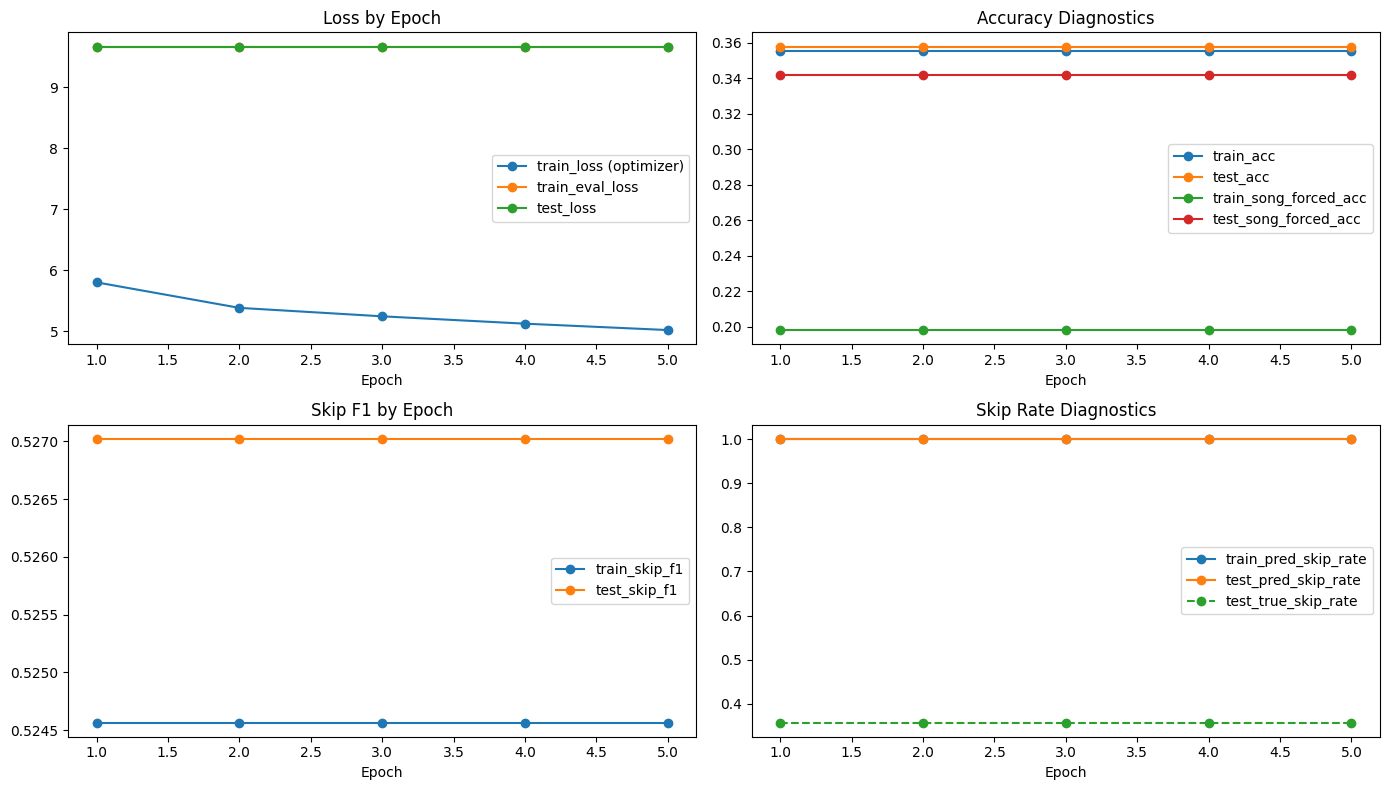

In [11]:
# Quick visual diagnostics
if 'history_df' in globals() and len(history_df) > 0:
    display(history_df.round(4))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Loss curves
    axes[0, 0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train_loss (optimizer)')
    axes[0, 0].plot(history_df['epoch'], history_df['train_eval_loss'], marker='o', label='train_eval_loss')
    axes[0, 0].plot(history_df['epoch'], history_df['test_loss'], marker='o', label='test_loss')
    axes[0, 0].set_title('Loss by Epoch')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()

    # Accuracy-like metrics
    axes[0, 1].plot(history_df['epoch'], history_df['train_acc'], marker='o', label='train_acc')
    axes[0, 1].plot(history_df['epoch'], history_df['test_acc'], marker='o', label='test_acc')
    axes[0, 1].plot(history_df['epoch'], history_df['train_song_forced_acc'], marker='o', label='train_song_forced_acc')
    axes[0, 1].plot(history_df['epoch'], history_df['test_song_forced_acc'], marker='o', label='test_song_forced_acc')
    axes[0, 1].set_title('Accuracy Diagnostics')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()

    # Skip F1
    axes[1, 0].plot(history_df['epoch'], history_df['train_skip_f1'], marker='o', label='train_skip_f1')
    axes[1, 0].plot(history_df['epoch'], history_df['skip_f1'], marker='o', label='test_skip_f1')
    axes[1, 0].set_title('Skip F1 by Epoch')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()

    # Skip rate collapse check
    axes[1, 1].plot(history_df['epoch'], history_df['train_pred_skip_rate'], marker='o', label='train_pred_skip_rate')
    axes[1, 1].plot(history_df['epoch'], history_df['test_pred_skip_rate'], marker='o', label='test_pred_skip_rate')
    axes[1, 1].plot(history_df['epoch'], history_df['test_true_skip_rate'], marker='o', linestyle='--', label='test_true_skip_rate')
    axes[1, 1].set_title('Skip Rate Diagnostics')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

## Evaluation + Report-Ready Results

This section adds:
- **Sanity checks** for label/token consistency.
- **Model vs baselines** table (`always_skip`, `most_frequent_song`).
- **Binary skip-vs-song confusion matrix** and report.
- **Song Top-K accuracy** (`Top-5`, `Top-10`) for a more realistic retrieval-style metric.


Sanity checks passed: target ids are in [1, vocab_size-1] and exclude PAD.
Evaluation Summary (model + baselines):


,model,loss,perplexity,overall_acc,song_acc,song_top5_acc,song_top10_acc,skip_precision,skip_recall,skip_f1,skip_bal_acc,skip_rate_true,skip_rate_pred
0,transformer,9.6687,15813.9956,0.3578,0.000,0.3421,0.3422,0.3578,1.0,0.527,0.5,0.3578,1.0
1,baseline_always_skip,NaN,NaN,0.3578,0.000,NaN,NaN,0.3578,1.0,0.527,0.5,0.3578,1.0
2,baseline_mode_song,NaN,NaN,0.2196,0.342,NaN,NaN,0.0000,0.0,0.000,0.5,0.3578,0.0


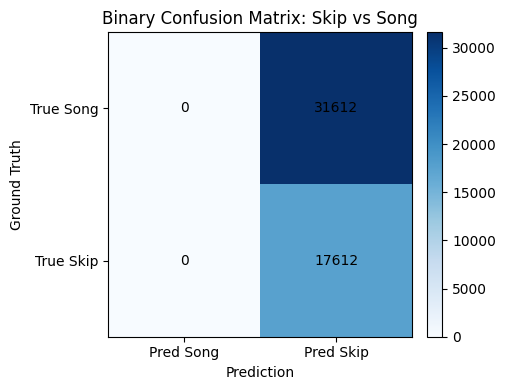

Binary classification report (skip vs song):
              precision    recall  f1-score   support

        song       0.00      0.00      0.00     31612
        skip       0.36      1.00      0.53     17612

    accuracy                           0.36     49224
   macro avg       0.18      0.50      0.26     49224
weighted avg       0.13      0.36      0.19     49224



In [12]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, classification_report

# ---------- Sanity checks (correctness guardrails) ----------
assert y_train.min() >= 1 and y_test.min() >= 1, "PAD token (0) should never appear as a target."
assert y_train.max() < vocab_size and y_test.max() < vocab_size, "Target token id exceeds vocab size."
print("Sanity checks passed: target ids are in [1, vocab_size-1] and exclude PAD.")


def collect_model_outputs(model, data_loader, criterion, topk_list=(5, 10)):
    model.eval()

    ys, preds = [], []
    total_loss = 0.0
    total_seen = 0

    max_k = max(topk_list) if len(topk_list) > 0 else 1
    topk_hits = {k: [] for k in topk_list}

    with torch.no_grad():
        for x, a, y in data_loader:
            x = x.to(DEVICE)
            a = a.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x, a)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)

            loss = criterion(logits, y)
            if not torch.isfinite(loss):
                continue

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_seen += bs

            pred = torch.argmax(logits, dim=1)
            ys.append(y.cpu().numpy())
            preds.append(pred.cpu().numpy())

            if len(topk_list) > 0:
                top_ids = torch.topk(logits, k=max_k, dim=1).indices.cpu().numpy()
                y_np = y.cpu().numpy()
                song_mask = y_np != 1

                if song_mask.any():
                    true_song = y_np[song_mask][:, None]
                    top_song = top_ids[song_mask]
                    for k in topk_list:
                        hits = (top_song[:, :k] == true_song).any(axis=1).astype(np.int64)
                        topk_hits[k].append(hits)

    if len(ys) == 0:
        return {
            "loss": np.nan,
            "perplexity": np.nan,
            "overall_acc": 0.0,
            "song_acc": 0.0,
            "skip_precision": 0.0,
            "skip_recall": 0.0,
            "skip_f1": 0.0,
            "skip_bal_acc": 0.0,
            "skip_rate_true": 0.0,
            "skip_rate_pred": 0.0,
            "song_top5_acc": np.nan,
            "song_top10_acc": np.nan,
        }, np.array([], dtype=np.int64), np.array([], dtype=np.int64)

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)

    song_mask = y_true != 1
    y_skip = (y_true == 1).astype(int)
    p_skip = (y_pred == 1).astype(int)

    skip_p, skip_r, skip_f1, _ = precision_recall_fscore_support(
        y_skip, p_skip, average="binary", zero_division=0
    )

    avg_loss = total_loss / max(1, total_seen)

    def _safe_mean(arrs):
        if len(arrs) == 0:
            return np.nan
        flat = np.concatenate(arrs)
        return float(np.mean(flat)) if len(flat) > 0 else np.nan

    metrics = {
        "loss": float(avg_loss),
        "perplexity": float(np.exp(np.clip(avg_loss, -20, 20))),
        "overall_acc": float(accuracy_score(y_true, y_pred)),
        "song_acc": float(accuracy_score(y_true[song_mask], y_pred[song_mask])) if song_mask.any() else 0.0,
        "skip_precision": float(skip_p),
        "skip_recall": float(skip_r),
        "skip_f1": float(skip_f1),
        "skip_bal_acc": float(balanced_accuracy_score(y_skip, p_skip)),
        "skip_rate_true": float(np.mean(y_skip)),
        "skip_rate_pred": float(np.mean(p_skip)),
        "song_top5_acc": _safe_mean(topk_hits.get(5, [])),
        "song_top10_acc": _safe_mean(topk_hits.get(10, [])),
    }

    return metrics, y_true, y_pred


def evaluate_fixed_predictor(y_true, y_pred, name):
    song_mask = y_true != 1
    y_skip = (y_true == 1).astype(int)
    p_skip = (y_pred == 1).astype(int)

    skip_p, skip_r, skip_f1, _ = precision_recall_fscore_support(
        y_skip, p_skip, average="binary", zero_division=0
    )

    return {
        "model": name,
        "loss": np.nan,
        "perplexity": np.nan,
        "overall_acc": float(accuracy_score(y_true, y_pred)),
        "song_acc": float(accuracy_score(y_true[song_mask], y_pred[song_mask])) if song_mask.any() else 0.0,
        "skip_precision": float(skip_p),
        "skip_recall": float(skip_r),
        "skip_f1": float(skip_f1),
        "skip_bal_acc": float(balanced_accuracy_score(y_skip, p_skip)),
        "skip_rate_true": float(np.mean(y_skip)),
        "skip_rate_pred": float(np.mean(p_skip)),
        "song_top5_acc": np.nan,
        "song_top10_acc": np.nan,
    }


if "criterion" not in globals():
    criterion = nn.CrossEntropyLoss()

model_metrics, y_true_model, y_pred_model = collect_model_outputs(model, test_loader, criterion, topk_list=(5, 10))

rows = []
rows.append({"model": "transformer", **model_metrics})

if len(y_true_model) > 0:
    # Baseline 1: always predict SKIP
    pred_all_skip = np.ones_like(y_true_model)
    rows.append(evaluate_fixed_predictor(y_true_model, pred_all_skip, "baseline_always_skip"))

    # Baseline 2: always predict most frequent song token from train targets
    song_targets_train = y_train[y_train != 1]
    if len(song_targets_train) > 0:
        mode_song_token = int(pd.Series(song_targets_train).value_counts().index[0])
    else:
        mode_song_token = 2
    pred_mode_song = np.full_like(y_true_model, mode_song_token)
    rows.append(evaluate_fixed_predictor(y_true_model, pred_mode_song, "baseline_mode_song"))

report_df = pd.DataFrame(rows)
show_cols = [
    "model",
    "loss",
    "perplexity",
    "overall_acc",
    "song_acc",
    "song_top5_acc",
    "song_top10_acc",
    "skip_precision",
    "skip_recall",
    "skip_f1",
    "skip_bal_acc",
    "skip_rate_true",
    "skip_rate_pred",
]

print("Evaluation Summary (model + baselines):")
display(report_df[show_cols].round(4))

if len(y_true_model) > 0:
    y_true_skip = (y_true_model == 1).astype(int)
    y_pred_skip = (y_pred_model == 1).astype(int)

    cm = confusion_matrix(y_true_skip, y_pred_skip, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], labels=["Pred Song", "Pred Skip"])
    ax.set_yticks([0, 1], labels=["True Song", "True Skip"])
    ax.set_title("Binary Confusion Matrix: Skip vs Song")
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground Truth")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    print("Binary classification report (skip vs song):")
    print(classification_report(y_true_skip, y_pred_skip, target_names=["song", "skip"], zero_division=0))

    pred_skip_rate = float(np.mean(y_pred_skip))
    if pred_skip_rate > 0.95:
        print("Warning: model predicts SKIP for >95% of test examples (collapse warning).")


In [13]:
# Simple decoding utilities
idx_to_title = {idx: title for title, idx in title_to_idx.items()}


def decode_token(token_id: int) -> str:
    if token_id == 0:
        return "<PAD>"
    if token_id == 1:
        return "<SKIP>"
    title_idx = token_id - 2
    return idx_to_title.get(title_idx, "<UNK_TITLE>")


def topk_next_tokens(history_tokens, k=5):
    history_tokens = history_tokens[-CONFIG["max_seq_len"]:]
    L = len(history_tokens)

    x = np.zeros((1, CONFIG["max_seq_len"]), dtype=np.int64)
    a = np.zeros((1, CONFIG["max_seq_len"]), dtype=np.int64)
    x[0, -L:] = np.array(history_tokens, dtype=np.int64)
    a[0, -L:] = 1

    model.eval()
    with torch.no_grad():
        logits = model(
            torch.from_numpy(x).to(DEVICE),
            torch.from_numpy(a).to(DEVICE),
        )
        logits = torch.nan_to_num(logits, nan=0.0, posinf=1e4, neginf=-1e4)
        probs = torch.softmax(logits, dim=1)
        probs = torch.nan_to_num(probs, nan=0.0, posinf=1.0, neginf=0.0)
        vals, ids = torch.topk(probs, k=k, dim=1)

    vals = vals[0].cpu().numpy()
    ids = ids[0].cpu().numpy()

    return [(int(i), decode_token(int(i)), float(v)) for i, v in zip(ids, vals)]


# Demo with one test sequence history
example_seq = test_seqs[0]
history = example_seq[:-1]
true_next = example_seq[-1]

print("History (last 10 tokens):", [decode_token(t) for t in history[-10:]])
print("True next:", decode_token(true_next))
print("Top-5 predictions:")
for tid, label, p in topk_next_tokens(history, k=5):
    print(f"  token={tid:<6} label={label:<25} prob={p:.4f}")


History (last 10 tokens): ['<SKIP>', 't_db945033-3dc5-4a22-8889-c72fd2781299', '<SKIP>', '<UNK_TITLE>', '<SKIP>', 't_bf496d77-9eb2-4fe1-80f7-2c7ecd6f9b8e', '<SKIP>', 't_1051bc37-1a73-4301-812b-f83ae0c9bbcd', '<SKIP>', 't_358c9cce-7a1e-4dd4-81de-206dda80363f']
True next: <SKIP>
Top-5 predictions:
  token=2      label=<UNK_TITLE>               prob=0.0001
  token=4      label=t_00042d9b-e795-41a9-89ad-504373dd4287 prob=0.0001
  token=5      label=t_000518e0-996c-46b0-9167-f831f5f8f513 prob=0.0001
  token=1      label=<SKIP>                    prob=0.0001
  token=3      label=t_0000dc06-0c00-4a09-9dc6-3bdad9c6f0e8 prob=0.0001


## Notes

- This is a compact baseline intended to match your requested modeling pattern exactly.
- Next practical upgrade: switch from one-target-per-example to full sequence loss per batch for faster training.
- If your true dataset has explicit `title`, `genre`, and `bpm` columns, set those names first in `CONFIG` candidates.
